In [ ]:
pip install polars

In [ ]:
# -*- coding: utf-8 -*-
"""
UAS Keamanan Data: Intrusion Detection System (IDS) - FINAL MASTER SCRIPT
Dataset: CSE-CIC-IDS2018
Role: Data Science Cybersecurity Specialist
"""

'\nUAS Keamanan Data: Intrusion Detection System (IDS) - FINAL MASTER SCRIPT\nDataset: CSE-CIC-IDS2018\nRole: Data Science Cybersecurity Specialist\n'

In [ ]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
print("--- [1] Inisialisasi Library ---")

# Instalasi paket yang mungkin belum ada di Colab standar
try:
    import gdown
    import xgboost
    import lightgbm
except ImportError:
    print("Menginstall library tambahan...")
    !pip install --quiet gdown xgboost lightgbm

import pandas as pd
import numpy as np
import glob
import os
import time
import joblib
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

# Scikit-Learn Components
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_recall_fscore_support, roc_curve, auc,
                             roc_auc_score, average_precision_score)

# [PENTING] Baseline Update: Menggunakan SGDClassifier sebagai Logistic Regression yang efisien
from sklearn.linear_model import LogisticRegression, SGDClassifier

# Advanced Models
import xgboost as xgb
import lightgbm as lgb

# Cek GPU
USE_GPU = False
try:
    gpu_info = os.popen('nvidia-smi').read()
    if 'NVIDIA-SMI' in gpu_info:
        print("✅ GPU Terdeteksi! XGBoost akan ngebut.")
        USE_GPU = True
    else:
        print("⚠️ GPU TIDAK terdeteksi. Script berjalan di CPU.")
except:
    pass

# Kosmetik Pandas
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

--- [1] Inisialisasi Library ---
✅ GPU Terdeteksi! XGBoost akan ngebut.


In [ ]:
import os
import glob
import zipfile
import shutil
# pastikan gdown sudah terinstall: pip install gdown
import gdown

# ==========================================
# 2. DATA DOWNLOAD & FIX STRUKTUR FOLDER
# ==========================================
print("\n--- [2] Persiapan Dataset ---")

# Folder tujuan utama
base_dir = "./data"
target_folder = os.path.join(base_dir, "cse-cic-ids2018")

# Pastikan folder data ada
os.makedirs(target_folder, exist_ok=True)

# Cek apakah folder kosong
if not os.listdir(target_folder):
    print("Dataset kosong. Memulai download...")

    file_id = "1Y_UkNaielHrHHSfXLfghF-Rq6ZCZ_651"
    url = f"https://drive.google.com/uc?id={file_id}"
    zip_filename = "downloaded_file.zip"

    try:
        gdown.download(url, zip_filename, quiet=False)
        print("Mengekstrak file ZIP...")
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            # PERUBAHAN: Ekstrak ke folder 'data' saja, bukan 'data/cse-cic-ids2018'
            # Karena zip-nya sudah punya folder 'cse-cic-ids2018' di dalamnya
            zip_ref.extractall(base_dir)

        print(f"✅ Berhasil diekstrak.")

        # Hapus file zip agar hemat tempat
        if os.path.exists(zip_filename):
            os.remove(zip_filename)

    except Exception as e:
        print(f"❌ Gagal: {e}")
else:
    print("✅ Dataset sudah ditemukan di folder lokal.")

# ==========================================
# LOGIKA PERBAIKAN STRUKTUR (AUTO-FIX)
# ==========================================
# Cek apakah terjadi double nesting: data/cse-cic-ids2018/cse-cic-ids2018
double_nested_path = os.path.join(target_folder, "cse-cic-ids2018")

if os.path.exists(double_nested_path) and os.path.isdir(double_nested_path):
    print("\n⚠️ Mendeteksi struktur folder ganda. Sedang memperbaiki...")

    # Ambil semua file dari folder dalam
    files_inside = os.listdir(double_nested_path)

    for filename in files_inside:
        src = os.path.join(double_nested_path, filename)
        dst = os.path.join(target_folder, filename)

        # Pindahkan file ke folder utama
        shutil.move(src, dst)

    # Hapus folder dalam yang sudah kosong
    os.rmdir(double_nested_path)
    print("✅ Struktur folder berhasil diperbaiki menjadi: data/cse-cic-ids2018/")

print(f"\nLokasi final data: {target_folder}")
# Cek isi folder untuk memastikan
print("Isi folder:", os.listdir(target_folder)[:5]) # Tampilkan 5 file pertama


--- [2] Persiapan Dataset ---
Dataset kosong. Memulai download...


Downloading...
From (original): https://drive.google.com/uc?id=1Y_UkNaielHrHHSfXLfghF-Rq6ZCZ_651
From (redirected): https://drive.google.com/uc?id=1Y_UkNaielHrHHSfXLfghF-Rq6ZCZ_651&confirm=t&uuid=da9f71fb-0e50-4251-aa33-e065086068f6
To: /content/downloaded_file.zip
100%|██████████| 1.67G/1.67G [00:12<00:00, 129MB/s] 


Mengekstrak file ZIP...
✅ Berhasil diekstrak.

Lokasi final data: ./data/cse-cic-ids2018
Isi folder: ['02-14-2018.csv', '02-28-2018.csv', '02-16-2018.csv', '02-15-2018.csv', '02-20-2018.csv']


In [ ]:
# ==========================================
# 3. DATA LOADING & MERGING
# ==========================================
print("\n--- [3] Membaca & Menggabungkan CSV ---")

path_ke_folder = "data/cse-cic-ids2018/"
# Mencari file CSV secara rekursif (jika ada subfolder hasil ekstrak)
semua_file_csv = glob.glob(os.path.join(path_ke_folder, "**/*.csv"), recursive=True)

if not semua_file_csv:
    # Fallback path jika struktur zip berbeda
    semua_file_csv = glob.glob(os.path.join("./data", "*.csv"))

list_df = []
SAMPLING_RATE = 1

if not semua_file_csv:
    raise ValueError("❌ Tidak ditemukan file CSV! Cek path hasil ekstrak.")

print(f"Ditemukan {len(semua_file_csv)} file CSV.")

for file_path in semua_file_csv:
    try:
        # Optimasi: Read hanya kolom penting jika memori mepet (Opsional)
        # df_temp = pd.read_csv(file_path, usecols=SELECTED_FEATURES + ['Label'])
        df_temp = pd.read_csv(file_path)

        # Tambah fitur tanggal
        nama_file = os.path.basename(file_path)
        tanggal_str = os.path.splitext(nama_file)[0]
        df_temp['file_date'] = tanggal_str

        # Sampling
        if SAMPLING_RATE < 1.0:
            df_temp = df_temp.sample(frac=SAMPLING_RATE, random_state=42)

        list_df.append(df_temp)
    except Exception as e:
        print(f"⚠️ Gagal baca {os.path.basename(file_path)}: {e}")

if list_df:
    df = pd.concat(list_df, ignore_index=True)
    print(f"✅ Total Data (Sampled): {df.shape}")
else:
    raise ValueError("Gagal memuat dataset.")


--- [3] Membaca & Menggabungkan CSV ---
Ditemukan 10 file CSV.


/tmp/ipython-input-2663808376.py:26: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path)
/tmp/ipython-input-2663808376.py:26: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path)
/tmp/ipython-input-2663808376.py:26: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,

✅ Total Data (Sampled): (11363098, 85)


In [ ]:
# ==========================================
# 4. PREPROCESSING & FEATURE SELECTION
# ==========================================
print("\n--- [4] Preprocessing & Cleaning ---")

df.columns = df.columns.str.strip()

# Fitur Relevan (Sesuai Paper CIC-IDS2018)
SELECTED_FEATURES = [
    'Dst Port', 'Protocol',
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
    'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
    'Flow Byts/s', 'Flow Pkts/s'
]

# Filter Kolom
cols = [c for c in SELECTED_FEATURES if c in df.columns]
if 'Label' in df.columns: cols.append('Label')
df_model = df[cols].copy()

# Cleaning Step 1: Handle problematic 'Label' entries (e.g., header rows)
# Convert Label to string and remove any 'Label' entries from the actual data
df_model['Label'] = df_model['Label'].astype(str).str.strip()
df_model = df_model[df_model['Label'] != 'Label'].copy() # Remove rows where Label is literally 'Label'

# Cleaning Step 2: Convert numeric columns and handle NaNs/Infinities
for col in SELECTED_FEATURES:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.dropna(inplace=True)

# Encoding
le = LabelEncoder()
df_model['Label_Encoded'] = le.fit_transform(df_model['Label'])
target_names = le.classes_
print(f"Kelas Serangan: {target_names}")

# Split Data
X = df_model.drop(columns=['Label', 'Label_Encoded'])
y = df_model['Label_Encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# ==========================================
# [UPDATE] 4B. PERSONALIZED PREPROCESSING
# ==========================================
print("\n--- [4B] Personalized Preprocessing (Split Strategy) ---")

# A. Preprocessing untuk Baseline (Logistic Regression)
# Model Linear WAJIB Scaling agar konvergen
print("A. Membuat dataset Ter-Scale (StandardScaler) untuk Logistic Regression...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# B. Preprocessing untuk Tree-Based (XGBoost & LightGBM)
# Model Tree TIDAK butuh scaling. Menggunakan data asli menjaga interpretabilitas.
# Kita menggunakan X_train dan X_test asli.
print("B. Menyiapkan dataset Asli (Raw) untuk XGBoost & LightGBM...")


--- [4] Preprocessing & Cleaning ---
Kelas Serangan: ['Benign' 'Bot' 'Brute Force -Web' 'Brute Force -XSS' 'DDOS attack-HOIC'
 'DDOS attack-LOIC-UDP' 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye'
 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Slowloris'
 'FTP-BruteForce' 'Infilteration' 'SQL Injection' 'SSH-Bruteforce']

--- [4B] Personalized Preprocessing (Split Strategy) ---
A. Membuat dataset Ter-Scale (StandardScaler) untuk Logistic Regression...
B. Menyiapkan dataset Asli (Raw) untuk XGBoost & LightGBM...


In [ ]:
# ==========================================
# 5. MODELING (Training)
# ==========================================
print("\n--- [5] Training Model ---")

model_metrics = {}
trained_models = {}

def hitung_metrik(y_true, y_pred, y_prob, name, time_taken):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    # ROC AUC (Safe Mode)
    try:
        roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted')
    except: roc_auc = 0.0

    # PR AUC
    try:
        n_classes = len(target_names)
        y_bin = label_binarize(y_true, classes=range(n_classes))
        pr_auc = average_precision_score(y_bin, y_prob, average='weighted')
    except: pr_auc = 0.0

    print(f"   ✅ {name}: Acc={acc:.4f}, F1={f1:.4f}, Time={time_taken:.2f}s")
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1,
            'ROC-AUC': roc_auc, 'PR-AUC': pr_auc, 'Training Time': time_taken}

# --- MODEL 1: Baseline (SGD Classifier) ---
# [UPDATE] Menggunakan SGDClassifier agar cepat di CPU
print("1. Training Logistic Regression (via SGD)...")
start = time.time()
base_model = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42, n_jobs=-1, early_stopping=True)
base_model.fit(X_train_scaled, y_train)
time_base = time.time() - start

model_metrics['Logistic Reg (SGD)'] = hitung_metrik(
    y_test,
    base_model.predict(X_test_scaled),
    base_model.predict_proba(X_test_scaled),
    'LogReg', time_base
)
trained_models['Logistic Reg (SGD)'] = base_model

# --- MODEL 2: XGBoost ---
print("2. Training XGBoost...")
dev = 'cuda' if USE_GPU else 'cpu'
start = time.time()
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', num_class=len(target_names),
    n_estimators=100, max_depth=6, learning_rate=0.1,
    tree_method='hist', device=dev, random_state=42
)
xgb_model.fit(X_train, y_train) # Data Raw
time_xgb = time.time() - start

model_metrics['XGBoost'] = hitung_metrik(
    y_test,
    xgb_model.predict(X_test),
    xgb_model.predict_proba(X_test),
    'XGBoost', time_xgb
)
trained_models['XGBoost'] = xgb_model

# --- MODEL 3: LightGBM ---
print("3. Training LightGBM...")
start = time.time()
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass', num_class=len(target_names),
    n_estimators=100, learning_rate=0.1, num_leaves=31, verbose=-1, random_state=42
)
lgbm_model.fit(X_train, y_train)
time_lgbm = time.time() - start

model_metrics['LightGBM'] = hitung_metrik(
    y_test,
    lgbm_model.predict(X_test),
    lgbm_model.predict_proba(X_test),
    'LightGBM', time_lgbm
)
trained_models['LightGBM'] = lgbm_model


--- [5] Training Model ---
1. Training Logistic Regression (via SGD)...
   ✅ LogReg: Acc=0.8517, F1=0.7937, Time=48.02s
2. Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [06:32:19] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


   ✅ XGBoost: Acc=0.9625, F1=0.9568, Time=15.75s
3. Training LightGBM...
   ✅ LightGBM: Acc=0.8240, F1=0.8164, Time=213.39s



--- [6] Visualisasi Evaluasi ---


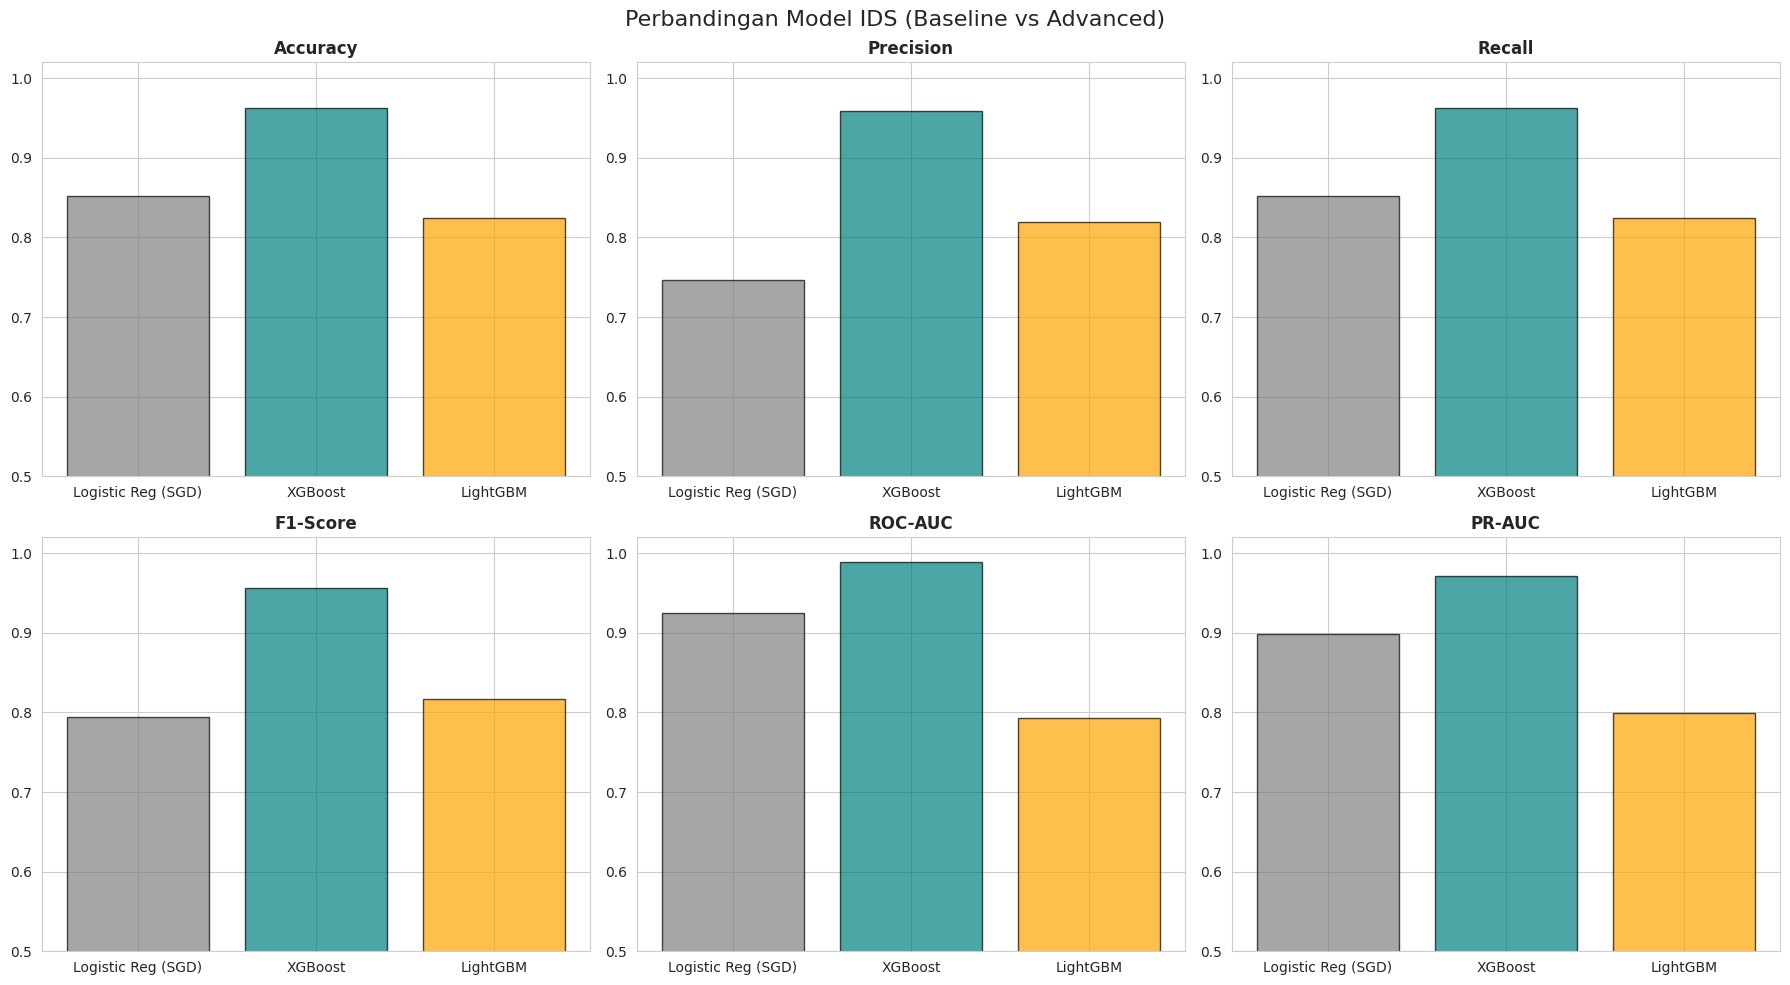


Visualisasi Confusion Matrix:


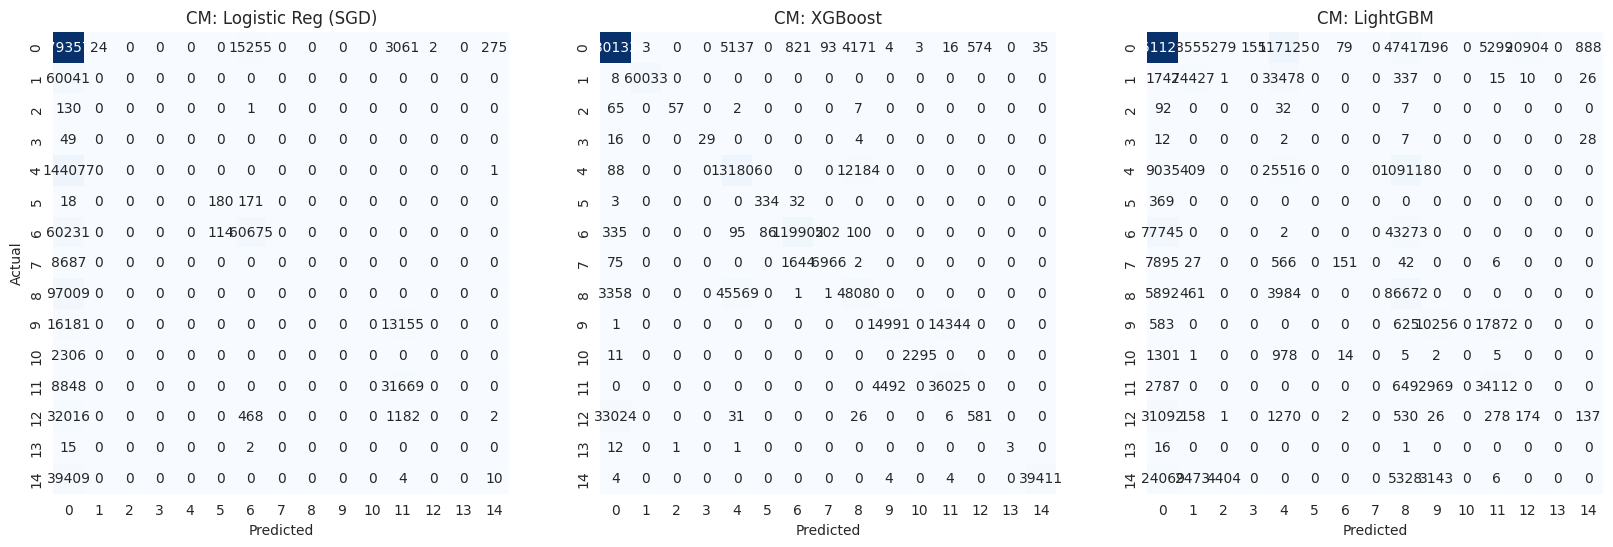

In [ ]:
# ==========================================
# 6. VISUALISASI MENDALAM
# ==========================================
print("\n--- [6] Visualisasi Evaluasi ---")

metrics_df = pd.DataFrame(model_metrics).T

# A. Bar Chart 6 Metrik
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Perbandingan Model IDS (Baseline vs Advanced)', fontsize=16)
met_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
colors = ['gray', 'teal', 'orange']
ax_flat = axes.flatten()

for i, m in enumerate(met_list):
    ax_flat[i].bar(metrics_df.index, metrics_df[m], color=colors, alpha=0.7, edgecolor='black')
    ax_flat[i].set_title(m, fontweight='bold')
    ax_flat[i].set_ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

# B. Confusion Matrix
print("\nVisualisasi Confusion Matrix:")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (name, model) in enumerate(trained_models.items()):
    if 'Logistic' in name: pred = model.predict(X_test_scaled)
    else: pred = model.predict(X_test)

    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'CM: {name}')
    axes[i].set_xlabel('Predicted')
    if i==0: axes[i].set_ylabel('Actual')
plt.show()

In [ ]:
# ==========================================
# 7. MITIGASI OTOMATIS
# ==========================================
print("\n--- [7] Simulasi Mitigasi (SOC Playbook) ---")

# Ambil Model Terbaik
best_name = metrics_df['F1-Score'].idxmax()
best_model = trained_models[best_name]
print(f"🏆 Menggunakan Model Terbaik: {best_name}")

# Simulasi Deteksi
sim_data = X_test.copy()
if 'Logistic' in best_name: preds = best_model.predict(X_test_scaled)
else: preds = best_model.predict(X_test)

sim_data['Predicted_Label'] = le.inverse_transform(preds)
# Ambil sampel serangan saja
attacks = sim_data[sim_data['Predicted_Label'] != 'Benign'].head(10)

logs = []
for _, row in attacks.iterrows():
    atk = row['Predicted_Label']
    ip = f"192.168.1.{np.random.randint(2, 250)}"
    port = row.get('Dst Port', 80)

    if "DoS" in atk:
        act1 = f"iptables -A INPUT -p tcp --dport {port} -m limit --limit 10/s -j ACCEPT"
        act2 = "Route Null0"
        scr = "ddos_mitigation.sh"
    elif "Brute" in atk:
        act1 = f"iptables -A INPUT -s {ip} -j DROP"
        act2 = "Lock Account AD"
        scr = "brute_force_check.py"
    else:
        act1 = "Alert SOC L1"
        act2 = "Deep Packet Inspection"
        scr = "general_triage.sh"

    logs.append({'Time': pd.Timestamp.now(), 'IP_Attacker': ip, 'Type': atk,
                 'Action_Primary': act1, 'Script': scr})

df_log = pd.DataFrame(logs)
if not df_log.empty:
    from IPython.display import display
    display(df_log)
    df_log.to_csv("SOC_Mitigation_Report.csv", index=False)
else:
    print("Aman. Tidak ada serangan terdeteksi di sampel.")


--- [7] Simulasi Mitigasi (SOC Playbook) ---
🏆 Menggunakan Model Terbaik: XGBoost


,Time,IP_Attacker,Type,Action_Primary,Script
0,2025-11-22 06:40:27.377530,192.168.1.194,Bot,Alert SOC L1,general_triage.sh
1,2025-11-22 06:40:27.377687,192.168.1.149,DDoS attacks-LOIC-HTTP,iptables -A INPUT -p tcp --dport 80 -m limit -...,ddos_mitigation.sh
2,2025-11-22 06:40:27.377781,192.168.1.35,DDOS attack-HOIC,Alert SOC L1,general_triage.sh
3,2025-11-22 06:40:27.377861,192.168.1.137,DDOS attack-HOIC,Alert SOC L1,general_triage.sh
4,2025-11-22 06:40:27.377929,192.168.1.207,DDOS attack-HOIC,Alert SOC L1,general_triage.sh
5,2025-11-22 06:40:27.377994,192.168.1.155,DDOS attack-HOIC,Alert SOC L1,general_triage.sh
6,2025-11-22 06:40:27.378056,192.168.1.160,FTP-BruteForce,iptables -A INPUT -s 192.168.1.160 -j DROP,brute_force_check.py
7,2025-11-22 06:40:27.378117,192.168.1.33,DDOS attack-HOIC,Alert SOC L1,general_triage.sh
8,2025-11-22 06:40:27.378176,192.168.1.231,DDoS attacks-LOIC-HTTP,iptables -A INPUT -p tcp --dport 80 -m limit -...,ddos_mitigation.sh
9,2025-11-22 06:40:27.378235,192.168.1.148,DDoS attacks-LOIC-HTTP,iptables -A INPUT -p tcp --dport 80 -m limit -...,ddos_mitigation.sh


In [ ]:
# ==========================================
# 8. SAVING MODEL (JOBLIB)
# ==========================================
print("\n--- [8] Deployment Saving ---")

artifacts = {
    "model_name": best_name,
    "model": best_model,
    "features": SELECTED_FEATURES,
    "label_encoder": le,
    "scaler": scaler if 'Logistic' in best_name else None
}

fname = "ids_model_final.pkl"
joblib.dump(artifacts, fname)
print(f"✅ Model System tersimpan: {fname}")
print("Siap didownload dan dideploy ke Flask/Streamlit.")


--- [8] Deployment Saving ---
✅ Model System tersimpan: ids_model_final.pkl
Siap didownload dan dideploy ke Flask/Streamlit.
